In [114]:
# Portfolio Optimization & Risk Analysis Using Python
#Monte Carlo Simulation | Sharpe Ratio | Risk Metrics

In [2]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [69]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
tickers = ['AAPL','MSFT','TSLA','JNJ','JPM']

raw_data = yf.download(tickers, start='2025-01-01', end='2026-01-01')

# Extract Adjusted Close properly
data = raw_data['Close']   # use Close (new Yahoo structure)

print(data.head())

# Save to CSV
data.to_csv('portfolio_data.csv')

[*********************100%***********************]  5 of 5 completed

Ticker            AAPL         JNJ         JPM        MSFT        TSLA
Date                                                                  
2025-01-02  242.525177  139.003433  233.969376  414.568604  379.279999
2025-01-03  242.037842  139.167526  237.166977  419.292877  410.440002
2025-01-06  243.668915  138.655960  236.010681  423.749756  411.049988
2025-01-07  240.894089  141.136429  238.284058  418.322296  394.359985
2025-01-08  241.381393  137.314407  238.244873  420.491272  394.940002


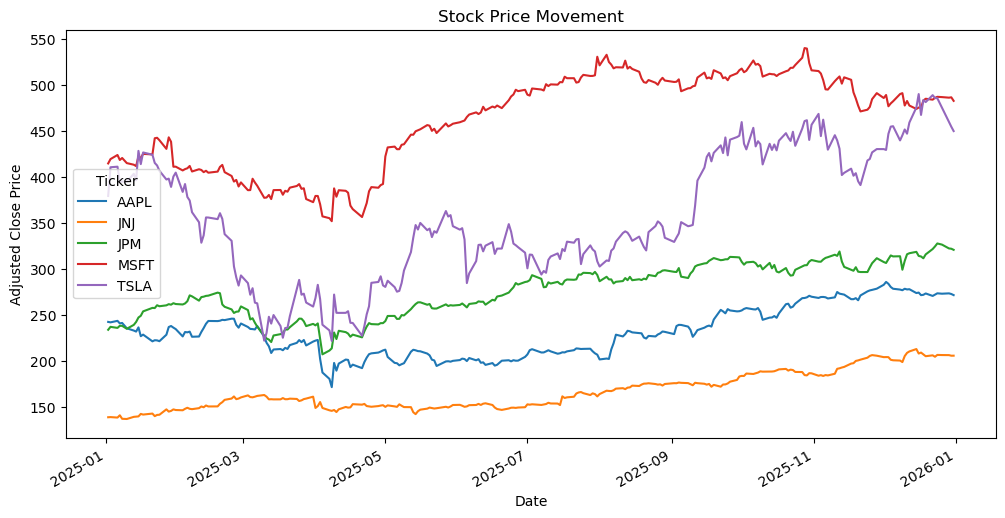

In [76]:
data.plot(figsize=(12,6))
plt.title("Stock Price Movement")
plt.ylabel("Adjusted Close Price")
plt.show()

In [77]:
print(data.isna().sum())

Ticker
AAPL    0
JNJ     0
JPM     0
MSFT    0
TSLA    0
dtype: int64


In [78]:
# portfolio analysis is done using returns
daily_returns = data.pct_change()
daily_returns = daily_returns.dropna()

print(daily_returns.head())

Ticker          AAPL       JNJ       JPM      MSFT      TSLA
Date                                                        
2025-01-03 -0.002009  0.001180  0.013667  0.011396  0.082156
2025-01-06  0.006739 -0.003676 -0.004875  0.010630  0.001486
2025-01-07 -0.011388  0.017889  0.009633 -0.012808 -0.040603
2025-01-08  0.002023 -0.027080 -0.000164  0.005185  0.001471
2025-01-10 -0.024104 -0.001476 -0.013409 -0.013214 -0.000506


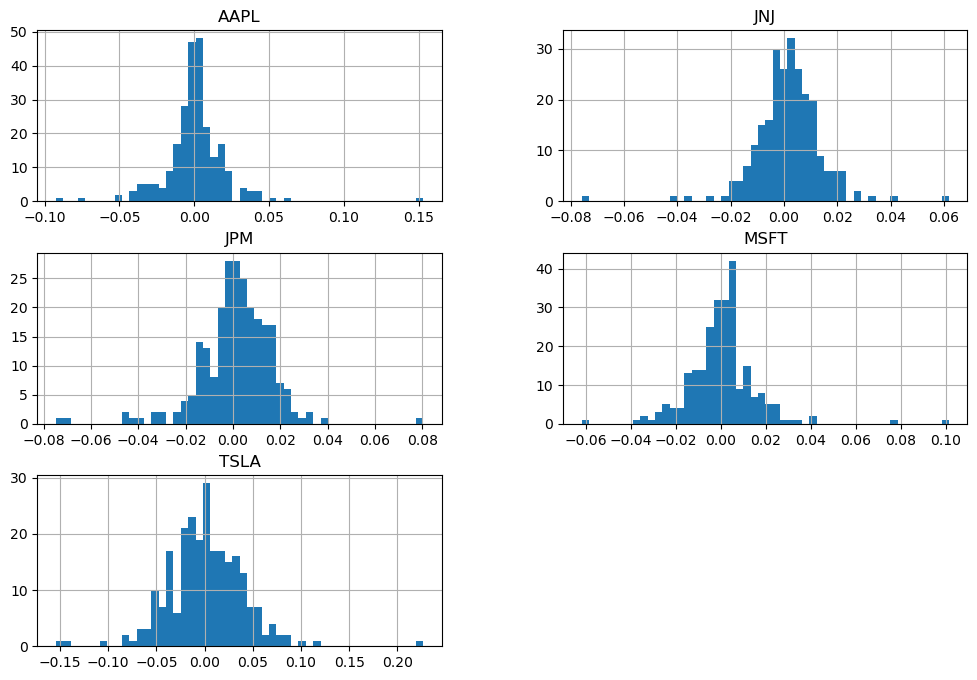

In [79]:
daily_returns.hist(figsize=(12,8), bins=50)
plt.show()

In [80]:
daily_returns.describe()

Ticker,AAPL,JNJ,JPM,MSFT,TSLA
count,249.000000,249.000000,249.000000,249.000000,249.000000
mean,0.000661,0.001654,0.001391,0.000725,0.001471
std,0.020450,0.012338,0.015686,0.015307,0.039880
min,-0.092456,-0.075916,-0.074838,-0.061809,-0.154262
25%,-0.006692,-0.004116,-0.004994,-0.006116,-0.021034
50%,0.000786,0.001938,0.001673,0.000780,0.000342
75%,0.006577,0.007879,0.010745,0.006139,0.024384
max,0.153288,0.061932,0.080555,0.101337,0.226900


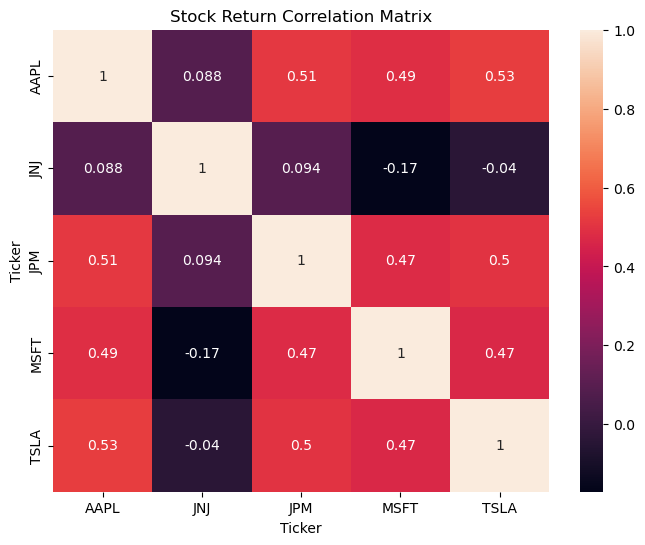

In [81]:
#Stock Correlation Heatmap
import seaborn as sns

corr_matrix = daily_returns.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True)
plt.title("Stock Return Correlation Matrix")
plt.show()

In [82]:
daily_returns.to_csv('daily_returns.csv')

In [115]:
## Equal Weight Portfolio Analysis
#We allocate 20% to each stock and evaluate performance.
#If I equally invest in all stocks, what happens?

In [83]:
weights = [0.2, 0.2, 0.2, 0.2, 0.2]  #Assign Portfolio Weights

In [84]:
#Calculate Portfolio Daily Return

portfolio_returns = daily_returns.dot(weights)

print(portfolio_returns.head())

Date
2025-01-03    0.021278
2025-01-06    0.002061
2025-01-07   -0.007455
2025-01-08   -0.003713
2025-01-10   -0.010542
dtype: float64


In [85]:
portfolio_returns.to_csv('portfolio_returns.csv')

In [86]:
portfolio_returns.describe()

count    249.000000
mean       0.001180
std        0.014879
min       -0.065732
25%       -0.005543
50%        0.001072
75%        0.008029
max        0.113709
dtype: float64

In [87]:
# Portfolio Performance (Cumulative Returns) 
# Calculate Cumulative Returns

portfolio_cum_returns = (1 + portfolio_returns).cumprod()
print(portfolio_cum_returns.head())

Date
2025-01-03    1.021278
2025-01-06    1.023382
2025-01-07    1.015753
2025-01-08    1.011981
2025-01-10    1.001313
dtype: float64


In [88]:
portfolio_cum_returns_pct = portfolio_cum_returns - 1 #Convert to % Return

In [89]:
portfolio_cum_returns_pct.to_csv('portfolio_cumulative_returns.csv') 

In [90]:
print(portfolio_cum_returns_pct.tail())

Date
2025-12-24    0.336516
2025-12-26    0.329108
2025-12-29    0.316965
2025-12-30    0.312437
2025-12-31    0.305542
dtype: float64


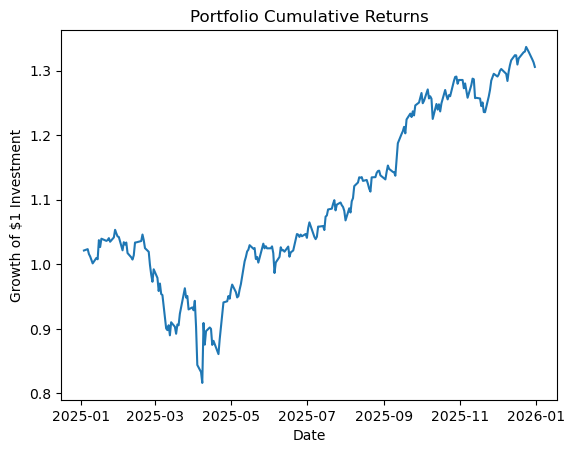

In [91]:
#portfolio performance over time.
cumulative_returns = (1 + portfolio_returns).cumprod()
plt.plot(cumulative_returns)
plt.title("Portfolio Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")
plt.show()

In [92]:
#Risk Metrics
#Portfolio Volatility (Annualised)

portfolio_volatility = portfolio_returns.std() * (252**0.5)
print(portfolio_volatility)

0.23619219471263583


In [93]:
# Sharpe Ratio
portfolio_sharpe = (portfolio_returns.mean() / portfolio_returns.std()) * (252**0.5)
print(portfolio_sharpe)

1.2594424035427236


In [94]:
# Maximum Drawdown (Biggest Loss Period) Worst peak-to-bottom loss
cum_returns = (1 + portfolio_returns).cumprod()
rolling_max = cum_returns.cummax()
drawdown = cum_returns / rolling_max - 1

max_drawdown = drawdown.min()
print(max_drawdown)

-0.22507046059044233


In [95]:
# Performance Attribution  -Who actually made the money?
# Contribution to Portfolio Return

contribution = daily_returns.mul(weights).sum()
print(contribution)

Ticker
AAPL    0.032893
JNJ     0.082389
JPM     0.069289
MSFT    0.036103
TSLA    0.073255
dtype: float64


In [96]:
#Convert to % Contribution
contribution_pct = contribution / contribution.sum()
print(contribution_pct)

Ticker
AAPL    0.111910
JNJ     0.280301
JPM     0.235734
MSFT    0.122829
TSLA    0.249226
dtype: float64


In [97]:
contribution_pct.to_csv('stock_contribution.csv')

In [98]:
portfolio_returns.to_csv('portfolio_returns.csv')
portfolio_cum_returns_pct.to_csv('portfolio_cumulative_returns.csv')
daily_returns.to_csv('daily_returns.csv')
contribution_pct.to_csv('stock_contribution.csv')

In [99]:
metrics = {
    "Annual Return": portfolio_cum_returns_pct.iloc[-1],
    "Volatility": portfolio_volatility,
    "Sharpe Ratio": portfolio_sharpe,
    "Max Drawdown": max_drawdown
}

import pandas as pd
metrics_df = pd.DataFrame.from_dict(metrics, orient='index', columns=['Value'])
metrics_df.to_csv('portfolio_metrics.csv')

print(metrics_df)

                  Value
Annual Return  0.305542
Volatility     0.236192
Sharpe Ratio   1.259442
Max Drawdown  -0.225070


In [116]:
# Portfolio Optimization Using Monte Carlo Simulation
#Goal: Find weight combination that maximizes Sharpe Ratio.

In [100]:
## Portfolio Optimisation using Monte Carlo Simulation


#daily average return × 252 trading days
import numpy as np

annual_returns = daily_returns.mean() * 252

In [101]:
# covariance matrix
cov_matrix = daily_returns.cov()*252

In [102]:
#Portfolio Performance Function
def portfolio_performance(weights, returns, cov_matrix):

    portfolio_return = np.dot(weights, returns)

    portfolio_volatility = np.sqrt(
        np.dot(weights.T, np.dot(cov_matrix, weights))
    )

    sharpe_ratio = portfolio_return / portfolio_volatility

    return portfolio_return, portfolio_volatility, sharpe_ratio

In [103]:
#Simulate Random Portfolios
num_portfolios = 10000

results = []
weights_record = []

for i in range(num_portfolios):

    weights = np.random.random(len(tickers))
    weights = weights / np.sum(weights)

    weights_record.append(weights)

    ret, vol, sharpe = portfolio_performance(
        weights,
        annual_returns,
        cov_matrix
    )

    results.append([ret, vol, sharpe])

In [104]:
#Convertingg Results to DataFrame
results_df = pd.DataFrame(
    results,
    columns=["Return","Volatility","Sharpe"]
)

In [105]:
#Find Best Portfolio
max_sharpe_idx = results_df["Sharpe"].idxmax()

best_portfolio = results_df.loc[max_sharpe_idx]
best_weights = weights_record[max_sharpe_idx]

In [106]:
#Display Optimal Weights
optimal_weights = pd.Series(best_weights, index=tickers)
print(optimal_weights)

AAPL    0.005016
MSFT    0.744832
TSLA    0.096960
JNJ     0.115085
JPM     0.038107
dtype: float64


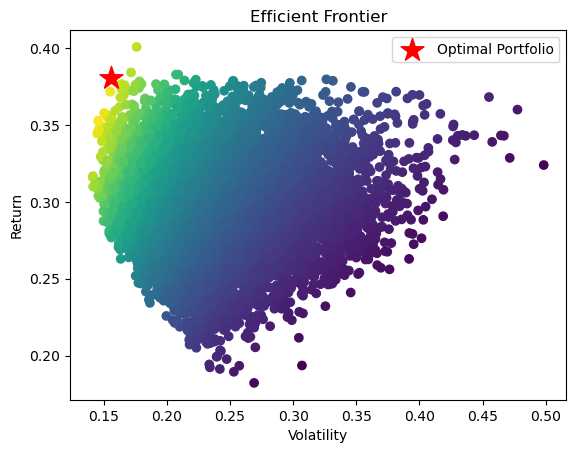

In [107]:
plt.scatter(
    results_df["Volatility"],
    results_df["Return"],
    c=results_df["Sharpe"],
    cmap="viridis"
)

plt.scatter(
    best_portfolio["Volatility"],
    best_portfolio["Return"],
    color="red",
    marker="*",
    s=300,
    label="Optimal Portfolio"
)

plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Efficient Frontier")

plt.legend()

plt.show()

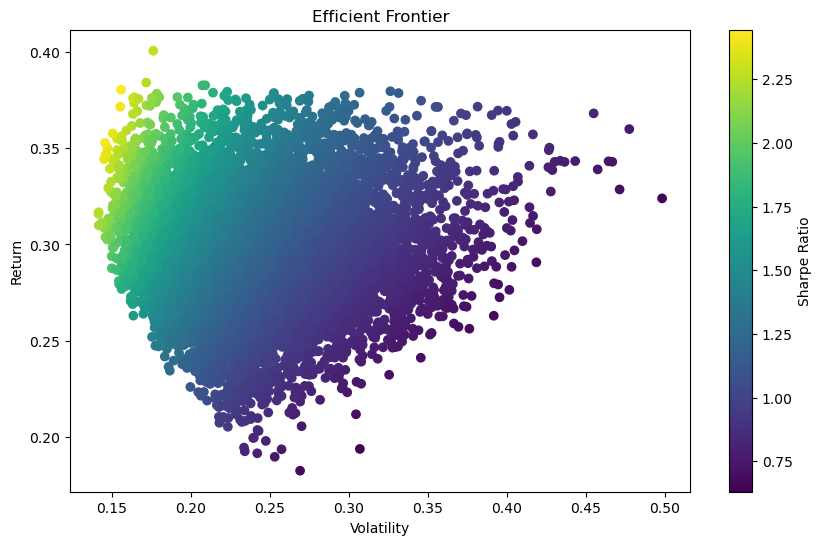

In [108]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    results_df["Volatility"],
    results_df["Return"],
    c=results_df["Sharpe"],
    cmap="viridis"
)

plt.colorbar(scatter, label="Sharpe Ratio")

plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Efficient Frontier")

plt.show()

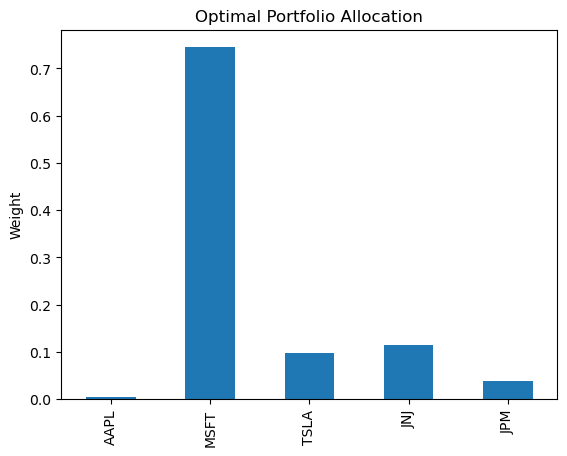

In [111]:
#the result of the optimisation.
optimal_weights.plot(kind="bar")
plt.title("Optimal Portfolio Allocation")
plt.ylabel("Weight")
plt.show()